## Clustering

### Importing Libraries and Loading dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
import datetime
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/superstore_clean.csv",
                 parse_dates=['Order_Date', 'Ship_Date'])

print(f"Data loaded: {df.shape}")

Data loaded: (6779, 28)


### Feature Selection

In [3]:
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer_ID').agg(
    Recency    = ('Order_Date', lambda x: (snapshot_date - x.max()).days),
    Frequency  = ('Order_ID', 'nunique'),
    Monetary   = ('Sales', 'sum'),
    Avg_Profit = ('Profit', 'mean'),
    Avg_Discount = ('Discount', 'mean')
).reset_index()

print("RFM Table created:")
display(rfm.head())
print(f"\nShape: {rfm.shape}")
print("\nDescriptive stats:")
display(rfm.describe().round(2))

RFM Table created:


,Customer_ID,Recency,Frequency,Monetary,Avg_Profit,Avg_Discount
0,AA-10315,185,5,596.980,9.976112,0.075000
1,AA-10375,20,9,406.440,8.569015,0.092308
2,AA-10480,260,4,652.732,12.813467,0.022222
3,AA-10645,56,6,702.860,9.098558,0.058333
4,AB-10015,1395,2,322.216,3.119625,0.100000



Shape: (787, 6)

Descriptive stats:


,Recency,Frequency,Monetary,Avg_Profit,Avg_Discount
count,787.00,787.00,787.00,787.00,787.00
mean,183.86,5.15,577.16,11.19,0.10
std,225.17,2.21,392.22,5.36,0.05
min,1.00,1.00,5.30,-6.02,0.00
25%,37.50,3.50,280.30,7.62,0.07
50%,97.00,5.00,507.58,11.03,0.10
75%,241.50,6.00,787.86,14.39,0.13
max,1395.00,12.00,2211.25,30.29,0.28


### Feature Scaling

In [4]:
features = ['Recency', 'Frequency', 'Monetary', 'Avg_Profit', 'Avg_Discount']
X = rfm[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled using StandardScaler")
print(f"   Features used: {features}")
print(f"   Scaled shape: {X_scaled.shape}")

Features scaled using StandardScaler
   Features used: ['Recency', 'Frequency', 'Monetary', 'Avg_Profit', 'Avg_Discount']
   Scaled shape: (787, 5)


### Finding Optimal K

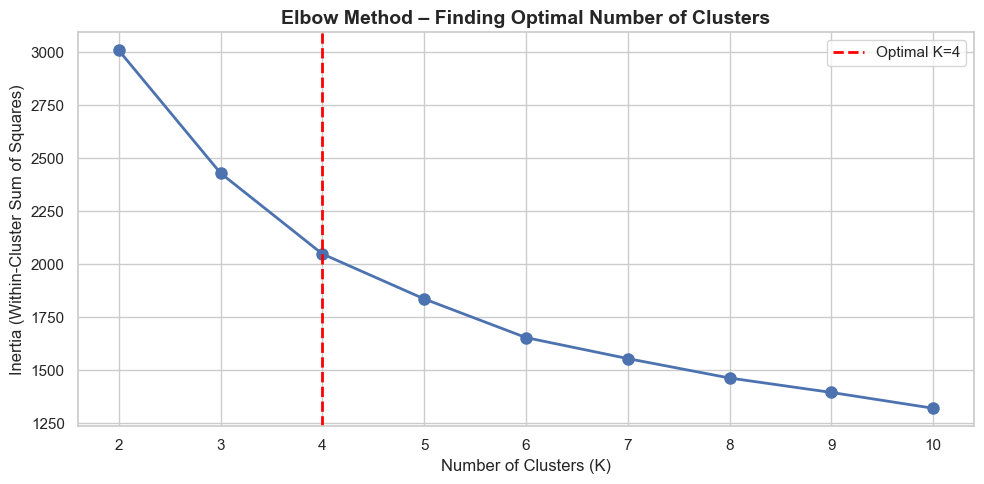

In [5]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', linewidth=2, label='Optimal K=4')
plt.title("Elbow Method – Finding Optimal Number of Clusters", 
          fontsize=14, fontweight='bold')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.legend()
plt.tight_layout()
plt.show()

### Silhouette Score

In [6]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"  K={k}: Silhouette Score = {score:.4f}")

best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nBest K by Silhouette Score: K={best_k} → Score={max(silhouette_scores):.4f}")

  K=2: Silhouette Score = 0.2121
  K=3: Silhouette Score = 0.2180
  K=4: Silhouette Score = 0.2295
  K=5: Silhouette Score = 0.2132
  K=6: Silhouette Score = 0.1966
  K=7: Silhouette Score = 0.1887
  K=8: Silhouette Score = 0.1913
  K=9: Silhouette Score = 0.1822
  K=10: Silhouette Score = 0.1814

Best K by Silhouette Score: K=4 → Score=0.2295


### Applying KMeans

In [7]:
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means clustering done with K={OPTIMAL_K}")
print("\nCustomer count per cluster:")
print(rfm['KMeans_Cluster'].value_counts().sort_index())

K-Means clustering done with K=4

Customer count per cluster:
KMeans_Cluster
0    245
1     75
2    285
3    182
Name: count, dtype: int64


### Cluster Profiles

----- Cluster Profiles (Mean Values) -----


,Recency,Frequency,Monetary,Avg_Profit,Avg_Discount
KMeans_Cluster,,,,,
0,97.40,7.53,979.15,12.34,0.10
1,728.76,2.83,330.98,9.97,0.12
2,149.49,4.13,409.19,13.90,0.06
3,129.50,4.51,400.49,5.91,0.15


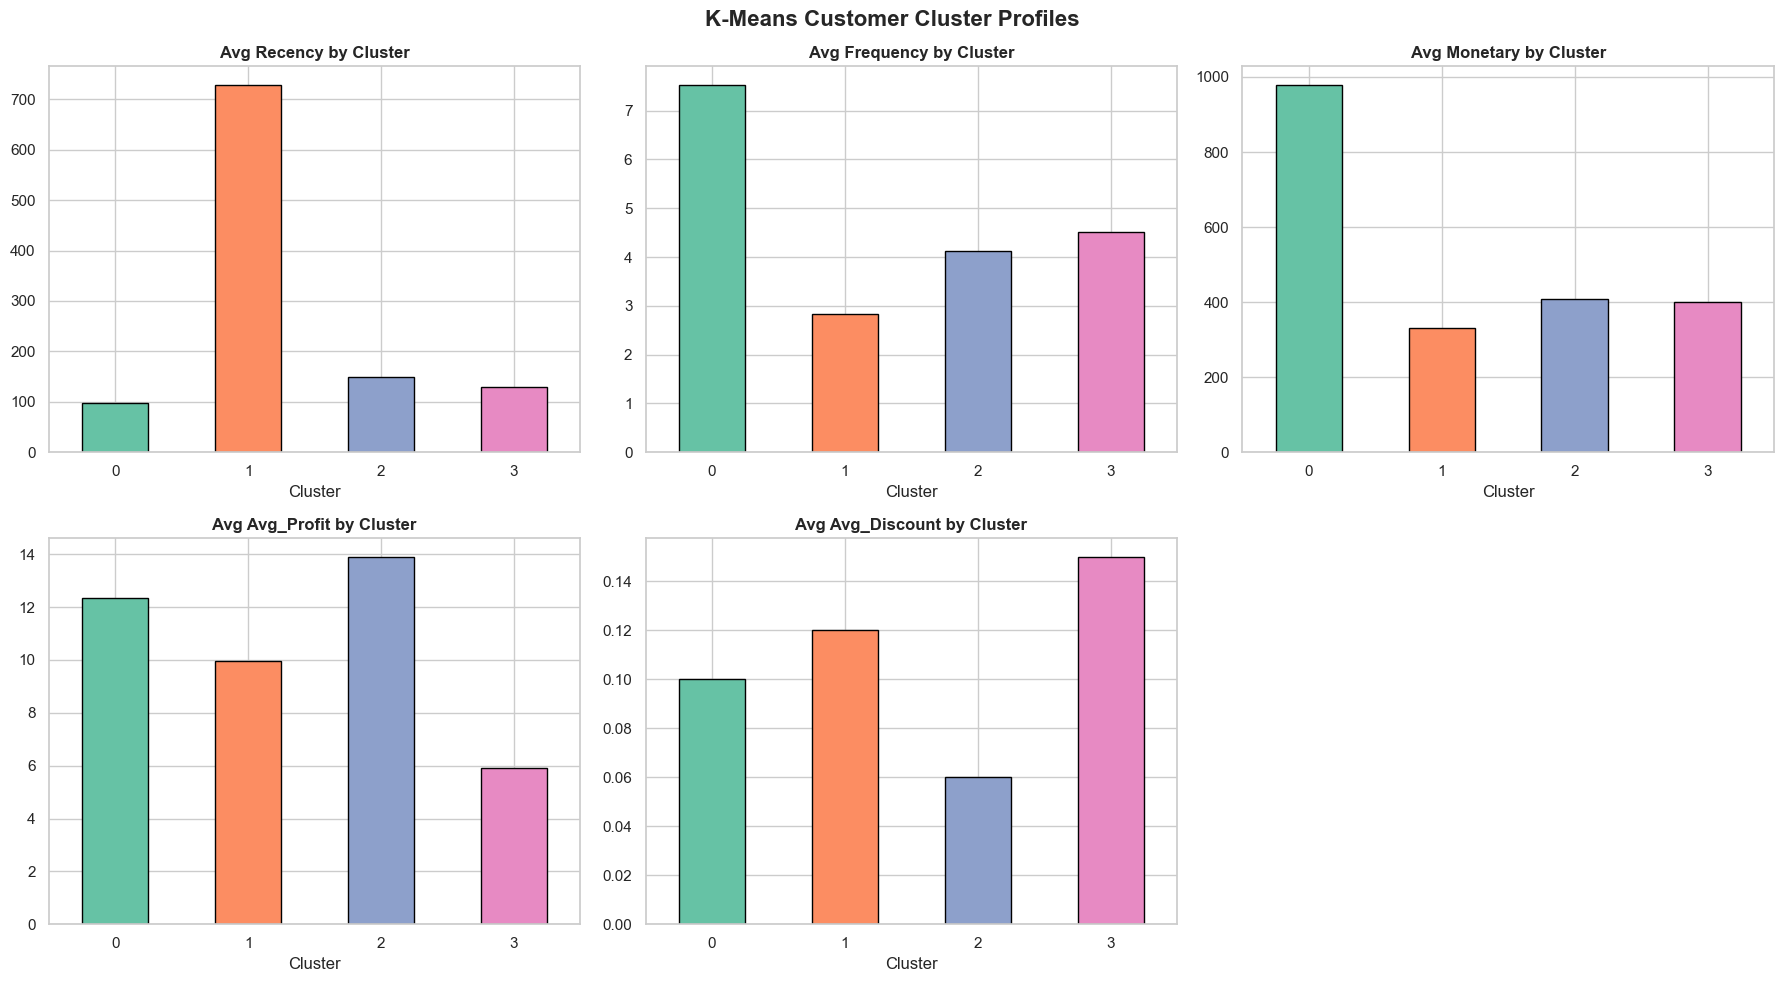

In [9]:
cluster_profile = rfm.groupby('KMeans_Cluster')[features].mean().round(2)
print("----- Cluster Profiles (Mean Values) -----")
display(cluster_profile)

# Assign business labels
cluster_labels = {
    0: "Loyal High-Value",
    1: "At-Risk Customers",
    2: "New/Occasional",
    3: "Champions"
}

# Plot cluster profiles as bar charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    cluster_profile[feature].plot(kind='bar', ax=axes[i], 
                                   color=sns.color_palette("Set2", OPTIMAL_K),
                                   edgecolor='black')
    axes[i].set_title(f"Avg {feature} by Cluster", fontweight='bold')
    axes[i].set_xlabel("Cluster")
    axes[i].tick_params(axis='x', rotation=0)

axes[-1].axis('off')  # Hide empty subplot
plt.suptitle("K-Means Customer Cluster Profiles", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

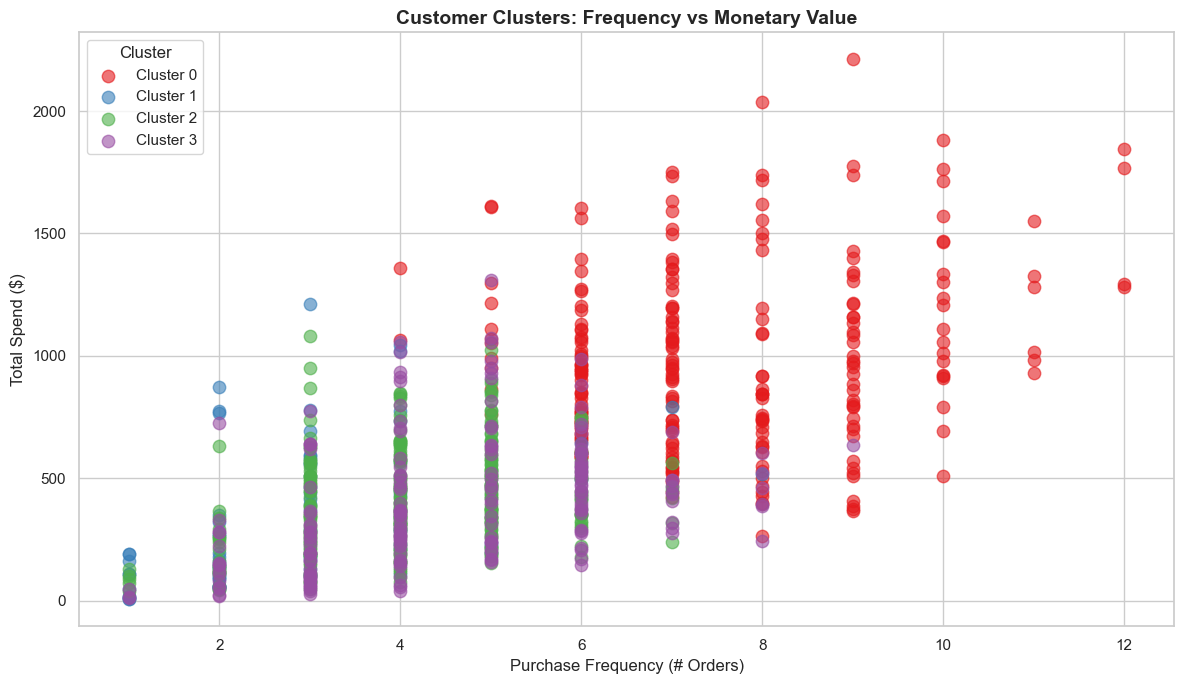

In [10]:
plt.figure(figsize=(12, 7))

colors_palette = sns.color_palette("Set1", OPTIMAL_K)

for cluster in range(OPTIMAL_K):
    subset = rfm[rfm['KMeans_Cluster'] == cluster]
    plt.scatter(subset['Frequency'], subset['Monetary'],
                label=f"Cluster {cluster}",
                alpha=0.6, s=80, color=colors_palette[cluster])

plt.title("Customer Clusters: Frequency vs Monetary Value", 
          fontsize=14, fontweight='bold')
plt.xlabel("Purchase Frequency (# Orders)")
plt.ylabel("Total Spend ($)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

### Hierarchical Clustering

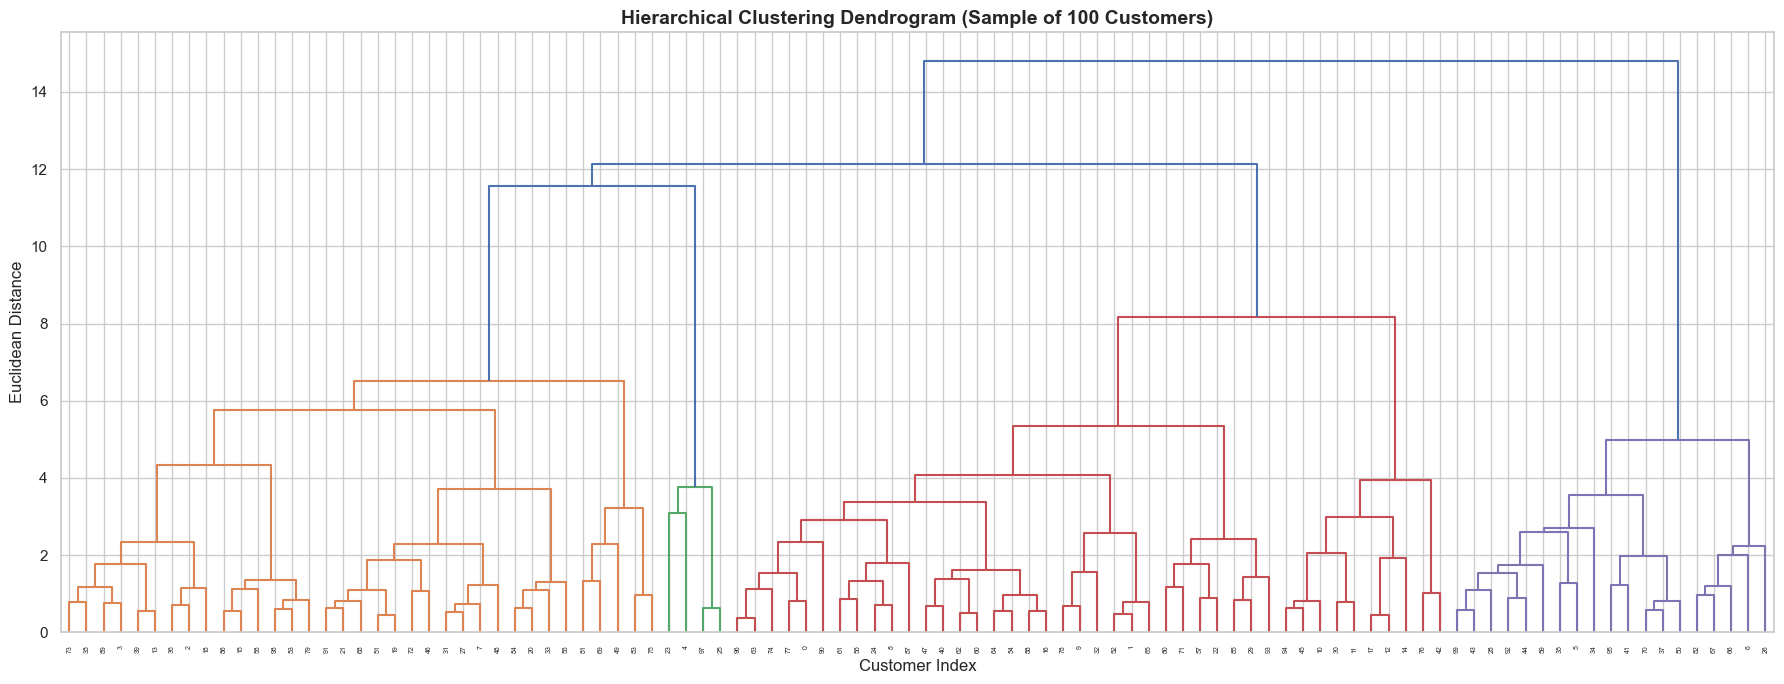

In [11]:
sample_X = X_scaled[:100]

linked = linkage(sample_X, method='ward')

plt.figure(figsize=(18, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           leaf_rotation=90,
           color_threshold=10)
plt.title("Hierarchical Clustering Dendrogram (Sample of 100 Customers)", 
          fontsize=14, fontweight='bold')
plt.xlabel("Customer Index")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()

In [12]:
hier = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
rfm['Hierarchical_Cluster'] = hier.fit_predict(X_scaled)

print("Hierarchical clustering done")
print("\nCustomer count per hierarchical cluster:")
print(rfm['Hierarchical_Cluster'].value_counts().sort_index())

# Compare KMeans vs Hierarchical
comparison = pd.crosstab(rfm['KMeans_Cluster'], rfm['Hierarchical_Cluster'],
                          rownames=['KMeans'], colnames=['Hierarchical'])
print("\n=== Cluster Agreement Matrix (KMeans vs Hierarchical) ===")
display(comparison)

Hierarchical clustering done

Customer count per hierarchical cluster:
Hierarchical_Cluster
0    318
1     95
2    238
3    136
Name: count, dtype: int64

=== Cluster Agreement Matrix (KMeans vs Hierarchical) ===


Hierarchical,0,1,2,3
KMeans,,,,
0,55,2,52,136
1,0,69,6,0
2,91,14,180,0
3,172,10,0,0


### Save Cluster Data

In [13]:
rfm.to_csv("../data/processed/customers_clustered.csv", index=False)
print("Clustered customer data saved")

print("\n------ CLUSTERING SUMMARY ------")
print(f"  Total customers analyzed: {len(rfm):,}")
print(f"  Clustering method: K-Means + Hierarchical")
print(f"  Optimal clusters: K={OPTIMAL_K}")
print(f"  Features used: {features}")
print(f"\n  Business Interpretation:")
for cid in range(OPTIMAL_K):
    subset = rfm[rfm['KMeans_Cluster'] == cid]
    print(f"  Cluster {cid}: {len(subset)} customers | "
          f"Avg Spend=${subset['Monetary'].mean():,.0f} | "
          f"Avg Orders={subset['Frequency'].mean():.1f}")

Clustered customer data saved

------ CLUSTERING SUMMARY ------
  Total customers analyzed: 787
  Clustering method: K-Means + Hierarchical
  Optimal clusters: K=4
  Features used: ['Recency', 'Frequency', 'Monetary', 'Avg_Profit', 'Avg_Discount']

  Business Interpretation:
  Cluster 0: 245 customers | Avg Spend=$979 | Avg Orders=7.5
  Cluster 1: 75 customers | Avg Spend=$331 | Avg Orders=2.8
  Cluster 2: 285 customers | Avg Spend=$409 | Avg Orders=4.1
  Cluster 3: 182 customers | Avg Spend=$400 | Avg Orders=4.5
